(60000, 784)
(10000, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


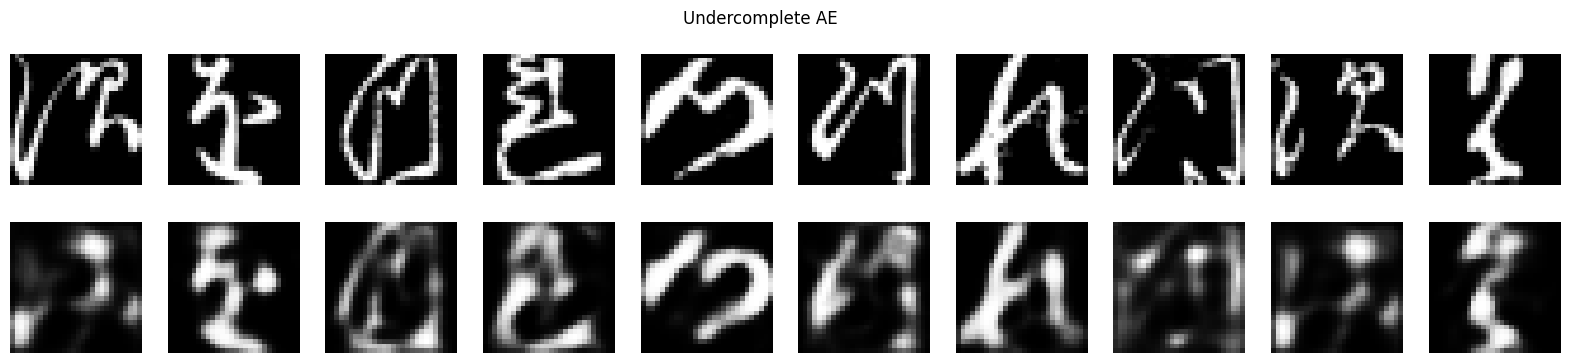

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


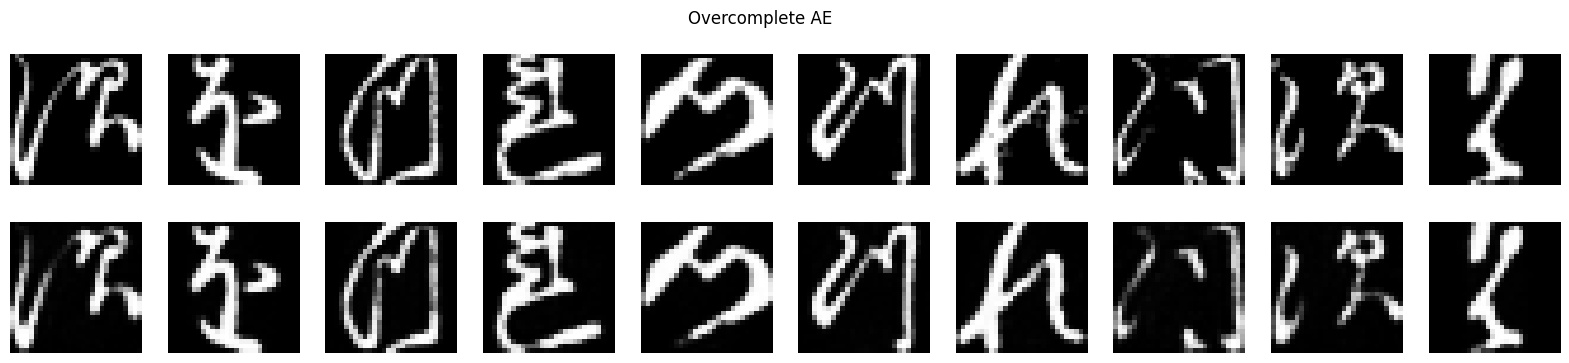

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


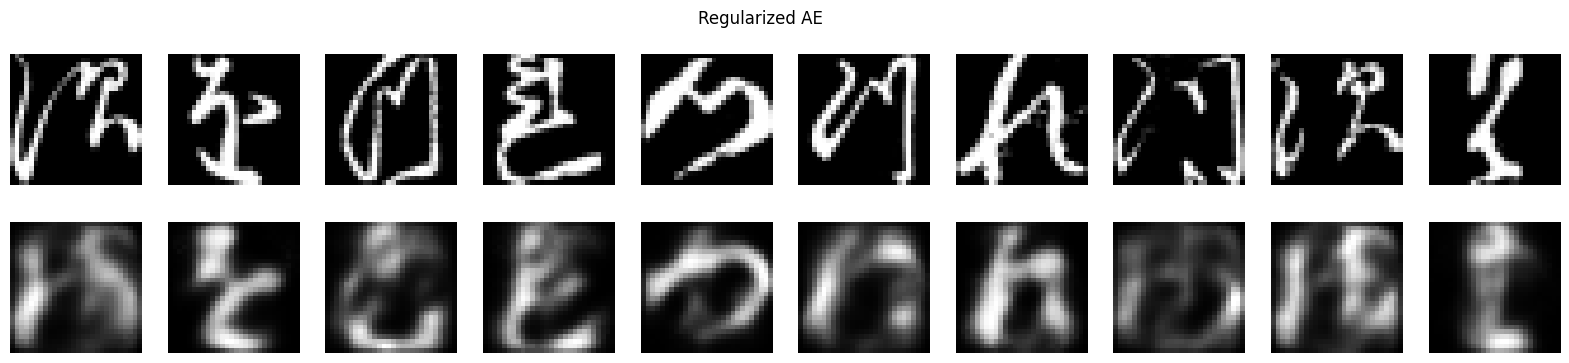

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


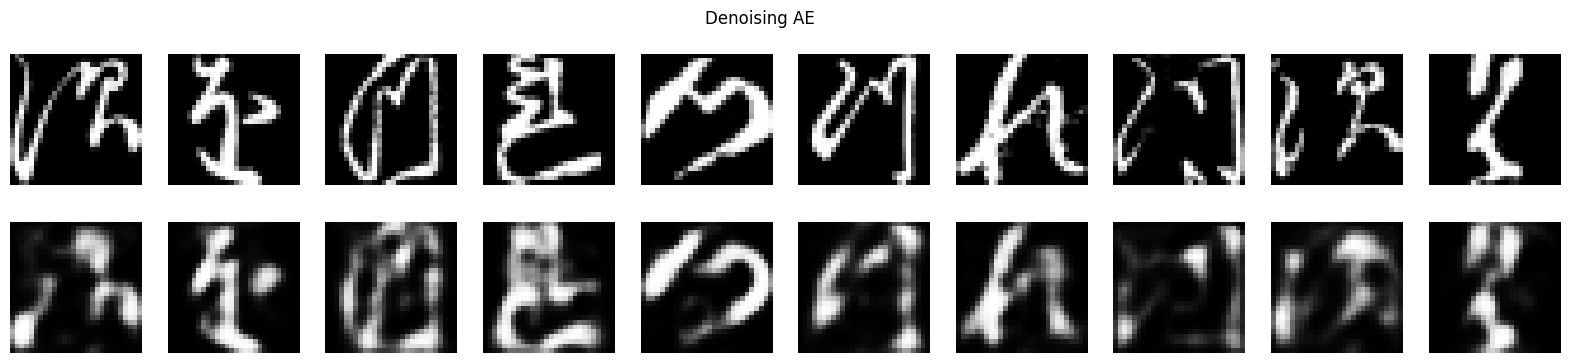

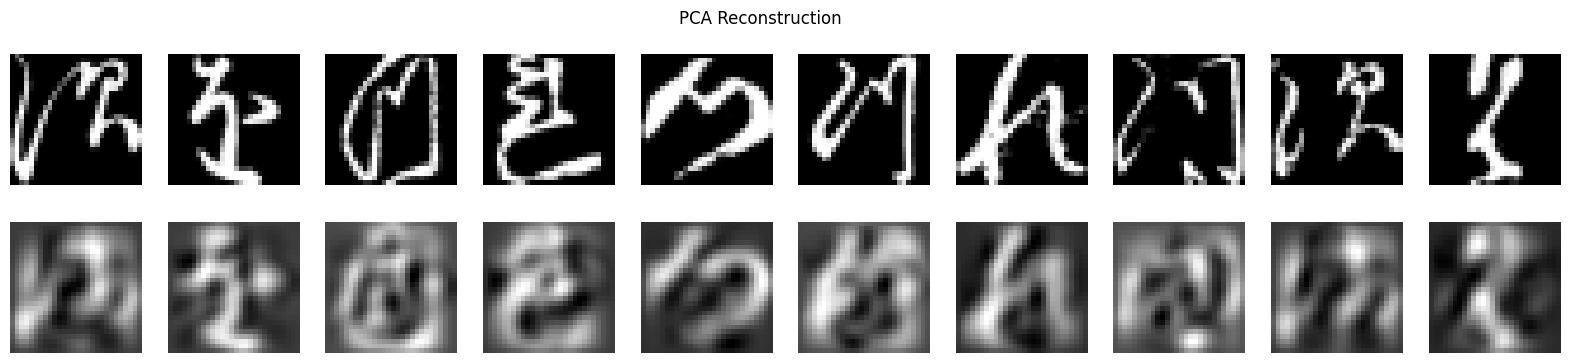

In [6]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import fetch_openml
from tensorflow.keras.layers import Input, Dense, GaussianNoise
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# =========================
# Load Data
# =========================

# Load dataset from file
kmnist = fetch_openml('Kuzushiji-MNIST', version=1)

x = kmnist.data
y = kmnist.target

# Convert to numpy (IMPORTANT)
x = x.to_numpy().astype('float32') / 255.

# Split manually (same as MNIST)
x_train = x[:60000]
x_test = x[60000:]

# Flatten already done (it's 784 features)
print(x_train.shape)  # (60000, 784)
print(x_test.shape)   # (10000, 784)

# FUNCTION TO BUILD AE
# =========================
def build_autoencoder(encoding_dim, l1=0.0):
    input_layer = Input(shape=(784,))
    
    encoded = Dense(encoding_dim, activation='relu',
                    activity_regularizer=tf.keras.regularizers.l1(l1))(input_layer)
    
    decoded = Dense(784, activation='sigmoid')(encoded)
    
    autoencoder = Model(input_layer, decoded)
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
    
    return autoencoder

# =========================
# 1. UNDERCOMPLETE AE
# =========================
ae_under = build_autoencoder(32)
ae_under.fit(x_train, x_train, epochs=10, batch_size=256, verbose=0)

# =========================
# 2. OVERCOMPLETE AE
# =========================
ae_over = build_autoencoder(512)
ae_over.fit(x_train, x_train, epochs=10, batch_size=256, verbose=0)

# =========================
# 3. REGULARIZED AE (L1)
# =========================
ae_reg = build_autoencoder(128, l1=1e-5)
ae_reg.fit(x_train, x_train, epochs=10, batch_size=256, verbose=0)

# =========================
# 4. DENOISING AE
# =========================
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

ae_denoise = build_autoencoder(64)
ae_denoise.fit(x_train_noisy, x_train, epochs=10, batch_size=256, verbose=0)

# =========================
# 5. PCA
# =========================
pca = PCA(n_components=32)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)
x_test_pca_recon = pca.inverse_transform(x_test_pca)

# =========================
# 6. SPARSE AE
# =========================
ae_sparse = build_autoencoder(128, l1=1e-4)
ae_sparse.fit(x_train, x_train, epochs=10, batch_size=256, verbose=0)

# =========================
# VISUALIZATION FUNCTION
# =========================
def show_results(model, data, title):
    decoded = model.predict(data[:10])
    
    plt.figure(figsize=(20,4))
    for i in range(10):
        # original
        ax = plt.subplot(2,10,i+1)
        plt.imshow(x_test[i].reshape(28,28), cmap='gray')
        plt.axis('off')
        
        # reconstructed
        ax = plt.subplot(2,10,i+11)
        plt.imshow(decoded[i].reshape(28,28), cmap='gray')
        plt.axis('off')
    
    plt.suptitle(title)
    plt.show()

# =========================
# DISPLAY RESULTS
# =========================
show_results(ae_under, x_test, "Undercomplete AE")
show_results(ae_over, x_test, "Overcomplete AE")
show_results(ae_reg, x_test, "Regularized AE")
show_results(ae_denoise, x_test_noisy, "Denoising AE")

# PCA Visualization
plt.figure(figsize=(20,4))
for i in range(10):
    ax = plt.subplot(2,10,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')
    
    ax = plt.subplot(2,10,i+11)
    plt.imshow(x_test_pca_recon[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.suptitle("PCA Reconstruction")
plt.show()

Undercomplete Autoencoder
The reconstructed images are not very clear
Important structures are preserved, but fine details are lost
Compression (784 → low dimension) leads to information loss

Conclusion: Works for dimensionality reduction but sacrifices quality

Complete / Overcomplete Autoencoder
Produces the best reconstruction quality
Output is very close to original image
However, it tends to learn identity mapping

Conclusion: Best visually, but may overfit and lack meaningful feature learning

Regularized Autoencoder
Reconstruction quality is worse than undercomplete AE
Regularization forces constraints, causing loss of detail
Helps prevent overfitting but reduces reconstruction sharpness

Conclusion: Trades accuracy for generalization

Denoising Autoencoder
Reconstruction is similar to undercomplete AE
Successfully removes noise but:
Still loses fine details
Performance depends on noise level

Conclusion: Good for robustness, not best for clarity

PCA
Produces the worst reconstruction
Images appear blurred and lack structure
Cannot capture non-linear patterns

Conclusion: Limited by linear transformation



Among all models, the complete (overcomplete) autoencoder produced the best visual reconstruction. However, it risks overfitting. Undercomplete and denoising autoencoders provide moderate performance with some loss of detail, while regularization further reduces reconstruction quality. PCA performs the worst due to its inability to capture non-linear relationships in image data.